# SDG Indicator Text Classification

Multi-label classification of Devex text documents into **SDG Goal 3** indicators (27 labels).

**Primary metric:** Hamming loss (lower is better)

---

**Google Colab:** Upload both CSV files to the same folder as this notebook, then *Runtime → Run all*.

**GitHub:** All code lives in this single notebook (`SGD_indicator.ipynb`).



In [1]:
# STEP 1: Install + import libraries
%pip install -q pandas numpy matplotlib seaborn scikit-learn beautifulsoup4 nltk

import warnings
warnings.filterwarnings("ignore")

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    hamming_loss, f1_score, precision_score, recall_score,
    classification_report, multilabel_confusion_matrix,
)

%matplotlib inline

try:
    from google.colab import files  # noqa: F401
    IN_COLAB = True
    print("Running in Google Colab — place Devex_train.csv and Devex_test_questions.csv in /content/")
except ImportError:
    IN_COLAB = False

print(f"pandas {pd.__version__} | numpy {np.__version__} | colab={IN_COLAB}")



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
pandas 3.0.3 | numpy 2.4.6 | colab=False


In [2]:
# STEP 2: Load datasets
from IPython.display import display

TRAIN_PATH = "Devex_train.csv"
TEST_PATH = "Devex_test_questions.csv"

train_df = pd.read_csv(TRAIN_PATH, encoding="latin-1")
test_df = pd.read_csv(TEST_PATH, encoding="latin-1")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# snip display of the train and test datasets
print("\nTrain data (first 2 rows):")
display(train_df.head(2))

print("\nTest data (first 2 rows):")
display(test_df.head(2))


Train shape: (2995, 15)
Test shape: (998, 3)

Train data (first 2 rows):


,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Test data (first 2 rows):


,Unique ID,Type,Text
0,49848,Organization,4th Sector Health: <p>4th Sector Health is a U...
1,52348,Organization,Action for Global Health: <p>Action for Global...


## STEP 3: Parse labels + exploratory data analysis (EDA)

Train labels are stored in `Label 1`–`Label 12` as indicator strings; unused slots are `NaN`/`NA`. We convert them to a binary matrix for multi-label modeling and explore the dataset before preprocessing.

In [3]:
LABEL_COLS = [f"Label {i}" for i in range(1, 13)]


def extract_labels(row):
    """Return active SDG indicator strings for one row (ignore NA/NaN/empty)."""
    labels = []
    for col in LABEL_COLS:
        value = row[col]
        if pd.isna(value):
            continue
        value = str(value).strip()
        if value and value.upper() != "NA":
            labels.append(value)
    return labels


train_df["labels"] = train_df.apply(extract_labels, axis=1)
train_df["n_labels"] = train_df["labels"].apply(len)

# Build fixed label vocabulary from training set only
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(train_df["labels"])
label_names = mlb.classes_

print(f"Number of unique SDG 3 indicators: {len(label_names)}")
print(f"Label matrix shape (samples × labels): {Y.shape}")
print(f"Labels per document — min: {train_df['n_labels'].min()}, "
      f"max: {train_df['n_labels'].max()}, "
      f"mean: {train_df['n_labels'].mean():.2f}")

# Shared split settings for preprocessing ablation, baseline, and experiments 1–10
RANDOM_STATE = 42
TEST_SIZE = 0.2
y = Y

display(train_df[["Unique ID", "Type", "n_labels", "labels"]].head(3))

Number of unique SDG 3 indicators: 27
Label matrix shape (samples × labels): (2995, 27)
Labels per document — min: 1, max: 10, mean: 1.98


,Unique ID,Type,n_labels,labels
0,12555,Grant,2,[3.b.2 - Total net official development assist...
1,14108,Grant,1,[3.b.2 - Total net official development assist...
2,23168,Organization,4,[3.d.1 - International Health Regulations (IHR...


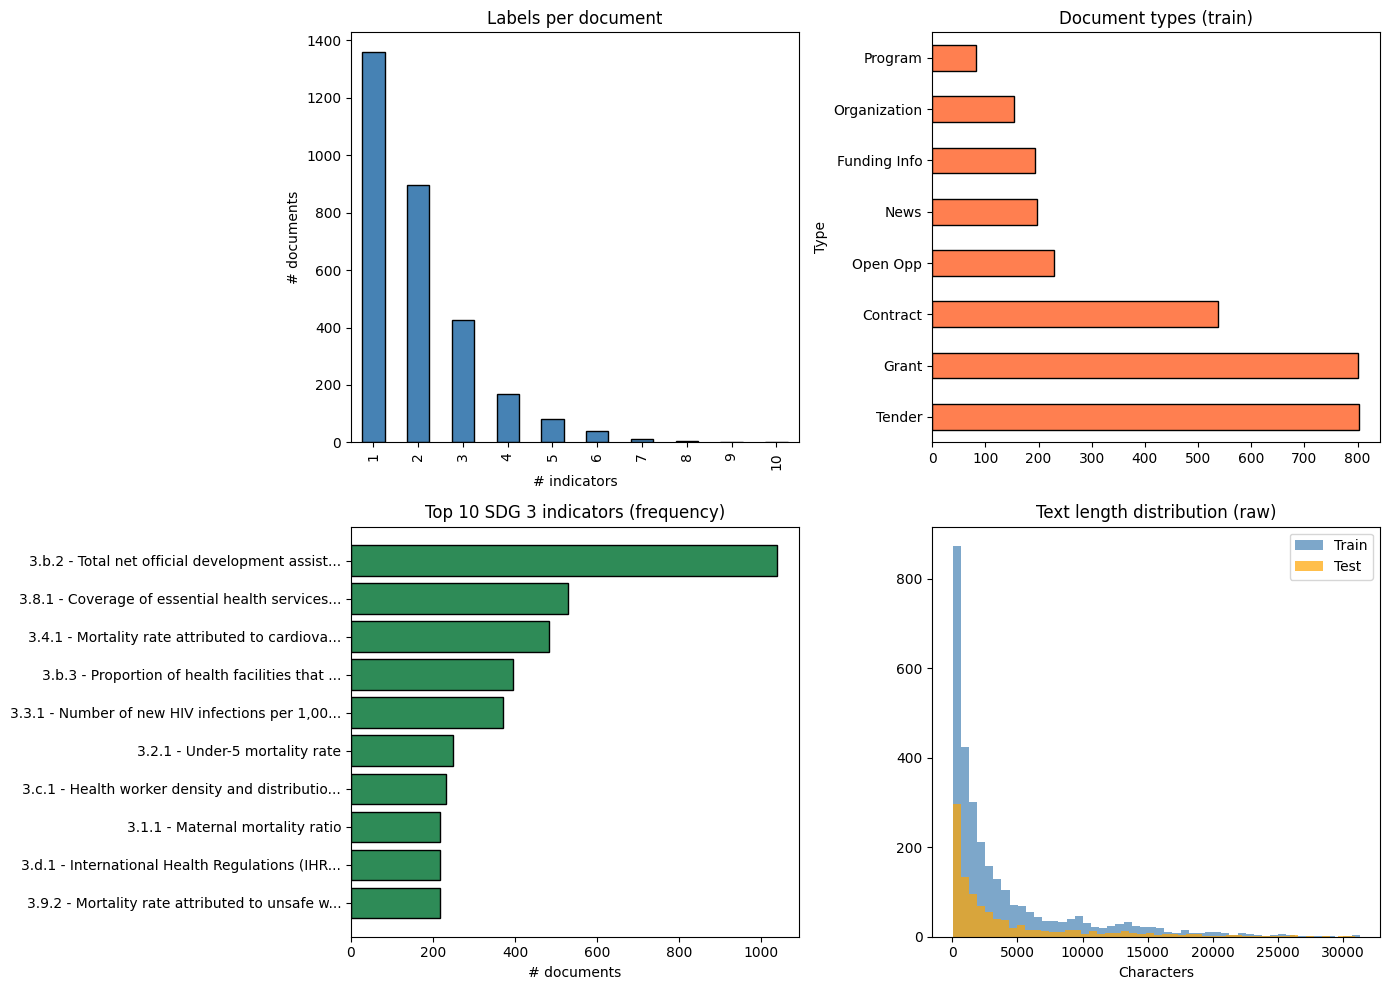


Label prevalence (documents containing each indicator):


,count
3.b.2 - Total net official development assistance to medical research and basic health sector,1040
"3.8.1 - Coverage of essential health services (defined as the average coverage of essential services based on tracer interventions that include reproductive, maternal, newborn and child health, infectious diseases, non-communicable diseases and service capacity and access, among the general and the most disadvantaged population)",529
"3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease",483
3.b.3 - Proportion of health facilities that have a core set of relevant essential medicines available and affordable on a sustainable basis,394
"3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations",371
3.2.1 - Under-5 mortality rate,249
3.c.1 - Health worker density and distribution,232
3.1.1 - Maternal mortality ratio,218
"3.9.2 - Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (exposure to unsafe Water, Sanitation and Hygiene for All (WASH) services)",217
3.d.1 - International Health Regulations (IHR) capacity and health emergency preparedness,217


In [4]:
# EDA visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Labels per document
train_df["n_labels"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 0], color="steelblue", edgecolor="black"
)
axes[0, 0].set_title("Labels per document")
axes[0, 0].set_xlabel("# indicators")
axes[0, 0].set_ylabel("# documents")

# 2) Document type distribution
train_df["Type"].value_counts().plot(
    kind="barh", ax=axes[0, 1], color="coral", edgecolor="black"
)
axes[0, 1].set_title("Document types (train)")

# 3) Top 10 most frequent indicators
label_counts = Y.sum(axis=0)
top_idx = np.argsort(label_counts)[::-1][:10]
top_labels = [label_names[i][:45] + "..." if len(label_names[i]) > 45 else label_names[i]
              for i in top_idx]
axes[1, 0].barh(top_labels[::-1], label_counts[top_idx][::-1], color="seagreen", edgecolor="black")
axes[1, 0].set_title("Top 10 SDG 3 indicators (frequency)")
axes[1, 0].set_xlabel("# documents")

# 4) Text length (characters) before cleaning
train_df["text_len"] = train_df["Text"].astype(str).str.len()
test_df["text_len"] = test_df["Text"].astype(str).str.len()
axes[1, 1].hist(train_df["text_len"], bins=50, alpha=0.7, label="Train", color="steelblue")
axes[1, 1].hist(test_df["text_len"], bins=50, alpha=0.7, label="Test", color="orange")
axes[1, 1].set_title("Text length distribution (raw)")
axes[1, 1].set_xlabel("Characters")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nLabel prevalence (documents containing each indicator):")
prevalence = pd.Series(label_counts, index=label_names).sort_values(ascending=False)
display(prevalence.head(10).to_frame("count"))

### Class imbalance analysis

The dataset is **highly imbalanced** across the 27 SDG 3 indicators. The most frequent label (3.b.2) appears in ~35% of documents, while several indicators appear in fewer than 50 training examples. This motivates `class_weight='balanced'` in our classifiers (tested explicitly in Experiment 9) and macro-F1 as a secondary metric alongside Hamming loss.


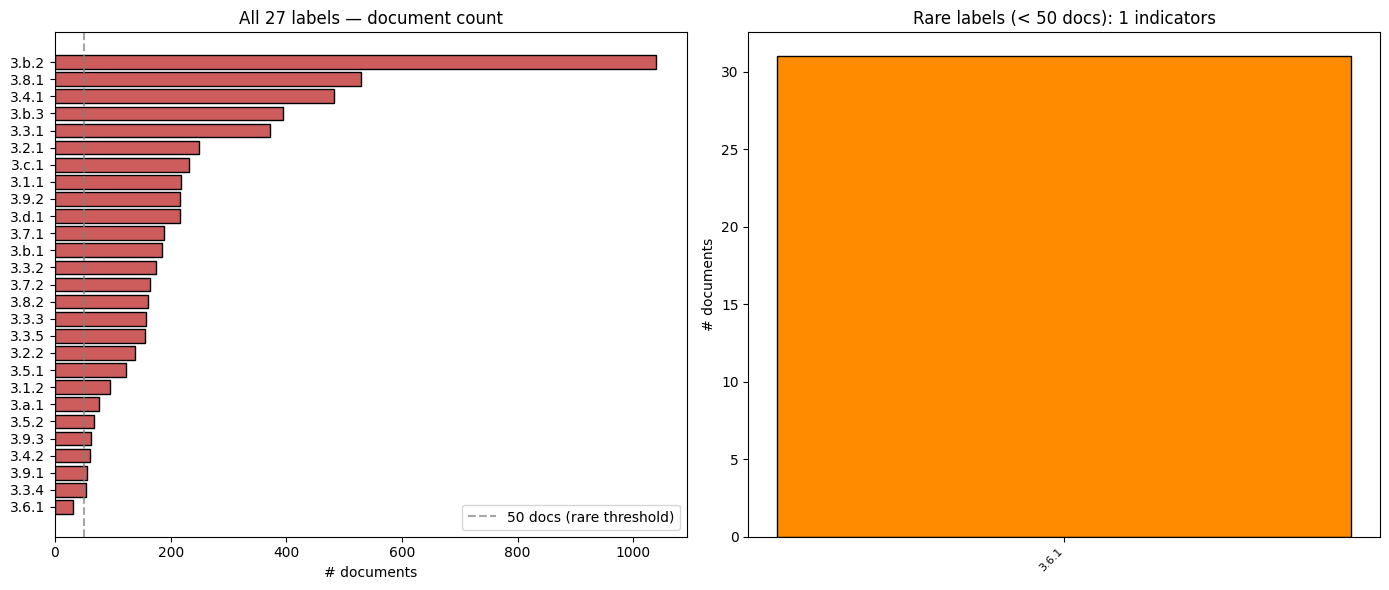

Most frequent: 3.b.2 - Total net official development assistance ... (1040 docs)
Least frequent: 3.6.1 - Death rate due to road traffic injuries... (31 docs)
Imbalance ratio (max/min): 33.5x


,indicator,count,pct_documents,imbalance_ratio
23,3.b.2 - Total net official development assista...,1040,34.72,1.0
16,3.8.1 - Coverage of essential health services ...,529,17.66,2.0
9,3.4.1 - Mortality rate attributed to cardiovas...,483,16.13,2.2
24,3.b.3 - Proportion of health facilities that h...,394,13.16,2.6
4,"3.3.1 - Number of new HIV infections per 1,000...",371,12.39,2.8


,indicator,count,pct_documents,imbalance_ratio
20,3.9.3 - Mortality rate attributed to unintenti...,63,2.10,16.5
10,3.4.2 - Suicide mortality rate,61,2.04,17.0
18,3.9.1 - Mortality rate attributed to household...,55,1.84,18.9
7,"3.3.4 - Hepatitis B incidence per 100,000 popu...",53,1.77,19.6
13,3.6.1 - Death rate due to road traffic injuries,31,1.04,33.5


In [5]:
# Class imbalance: full label distribution + imbalance ratio
label_counts = Y.sum(axis=0)
prevalence = pd.Series(label_counts, index=label_names).sort_values(ascending=False)
max_count = prevalence.max()
min_count = prevalence.min()

imbalance_df = pd.DataFrame({
    "indicator": label_names,
    "count": label_counts,
    "pct_documents": (label_counts / len(train_df) * 100).round(2),
    "imbalance_ratio": (max_count / np.maximum(label_counts, 1)).round(1),
}).sort_values("count", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
short_all = imbalance_df["indicator"].str.replace(r"^(\d+\.\S+) - .*", r"\1", regex=True)
axes[0].barh(short_all.iloc[::-1], imbalance_df["count"].iloc[::-1], color="indianred", edgecolor="black")
axes[0].set_title("All 27 labels — document count")
axes[0].set_xlabel("# documents")
axes[0].axvline(50, color="gray", linestyle="--", alpha=0.7, label="50 docs (rare threshold)")
axes[0].legend()

rare = imbalance_df[imbalance_df["count"] < 50]
axes[1].bar(range(len(rare)), rare["count"], color="darkorange", edgecolor="black")
axes[1].set_xticks(range(len(rare)))
axes[1].set_xticklabels(
    rare["indicator"].str.replace(r"^(\d+\.\S+) - .*", r"\1", regex=True),
    rotation=45, ha="right", fontsize=8,
)
axes[1].set_title(f"Rare labels (< 50 docs): {len(rare)} indicators")
axes[1].set_ylabel("# documents")
plt.tight_layout()
plt.show()

print(f"Most frequent: {prevalence.index[0][:50]}... ({int(max_count)} docs)")
print(f"Least frequent: {prevalence.index[-1][:50]}... ({int(min_count)} docs)")
print(f"Imbalance ratio (max/min): {max_count/min_count:.1f}x")
display(imbalance_df.head(5))
display(imbalance_df.tail(5))


### Label co-occurrence analysis

In multi-label problems, labels are not independent — documents often map to several related SDG 3 indicators. We compute the **co-occurrence matrix** (how often each pair of labels appears in the same document) to understand label correlations that One-vs-Rest classifiers must handle.


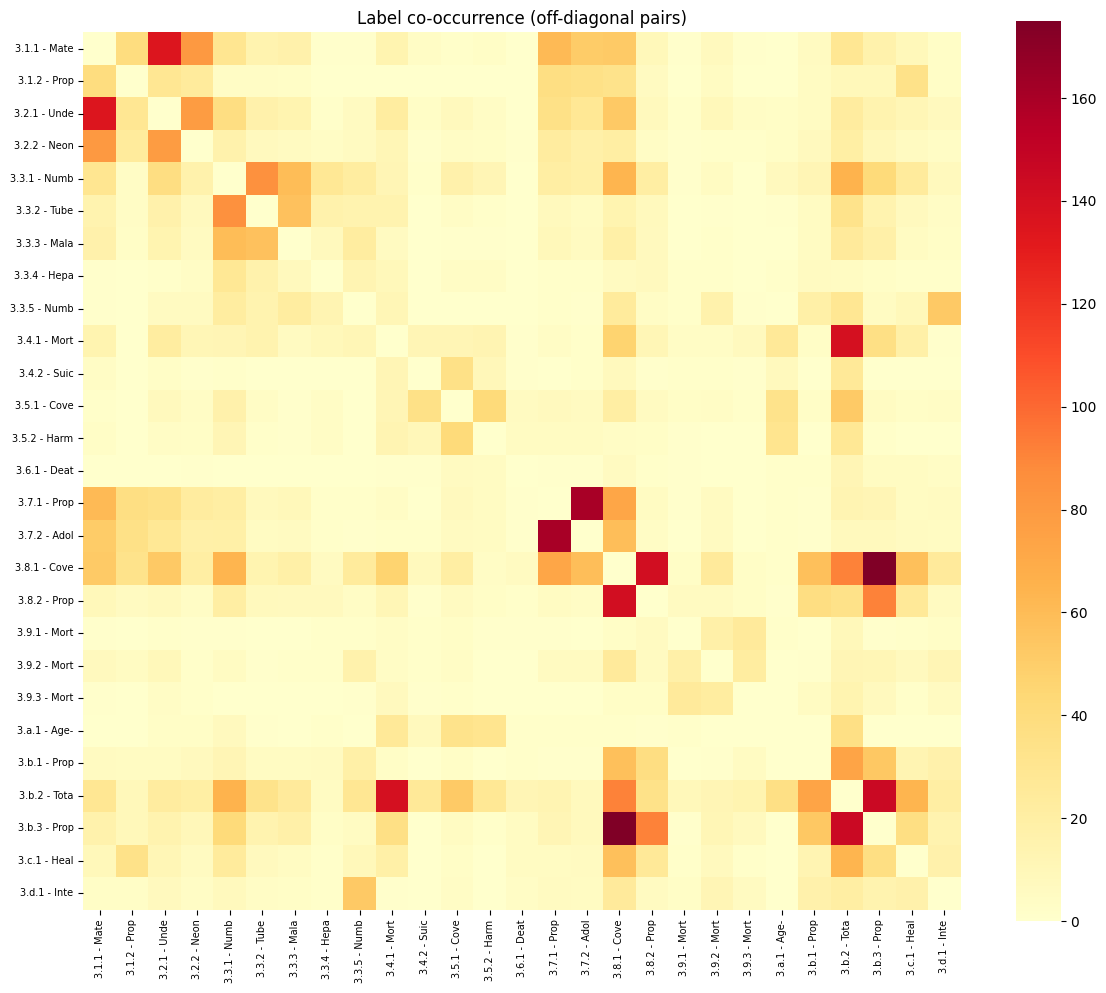

Top 10 co-occurring label pairs:


,label_a,label_b,co_count
256,3.8.1 - Coverage of essential health services ...,3.b.3 - Proportion of health facilities that h...,175
229,3.7.1 - Proportion of women of reproductive ag...,3.7.2 - Adolescent birth rate (aged 10_14 year...,160
291,3.b.2 - Total net official development assista...,3.b.3 - Proportion of health facilities that h...,145
249,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,141
179,3.4.1 - Mortality rate attributed to cardiovas...,3.b.2 - Total net official development assista...,140
1,3.1.1 - Maternal mortality ratio,3.2.1 - Under-5 mortality rate,135
255,3.8.1 - Coverage of essential health services ...,3.b.2 - Total net official development assista...,91
265,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,91
85,"3.3.1 - Number of new HIV infections per 1,000...","3.3.2 - Tuberculosis incidence per 100,000 pop...",85
2,3.1.1 - Maternal mortality ratio,3.2.2 - Neonatal mortality rate,80


In [6]:
# Label co-occurrence matrix (27 x 27)
cooccur = Y.T @ Y
np.fill_diagonal(cooccur, 0)

short_names = [n[:12] for n in label_names]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cooccur, xticklabels=short_names, yticklabels=short_names,
    cmap="YlOrRd", ax=ax, square=True,
)
ax.set_title("Label co-occurrence (off-diagonal pairs)")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

pairs = []
for i in range(len(label_names)):
    for j in range(i + 1, len(label_names)):
        if cooccur[i, j] > 0:
            pairs.append((label_names[i], label_names[j], int(cooccur[i, j])))
pairs_df = pd.DataFrame(pairs, columns=["label_a", "label_b", "co_count"]).sort_values("co_count", ascending=False)
print("Top 10 co-occurring label pairs:")
display(pairs_df.head(10))


## STEP 4: Text preprocessing pipeline

We apply a **staged preprocessing pipeline** and compare each stage as an ablation experiment:

| Stage | What it does | Rationale |
|-------|--------------|-----------|
| HTML removal | Strip tags via BeautifulSoup | Raw HTML adds noise; Experiment 4 confirms cleaning helps |
| Lowercasing | `text.lower()` | Reduces vocabulary fragmentation (Grant vs grant) |
| Stopword removal | Remove English function words | Tested at token level *and* via TF-IDF `stop_words` |
| Lemmatization | WordNet lemmatizer | Collapses inflected forms to base lemmas |

The baseline model uses the **best preprocessing variant** from the ablation below.


In [7]:
STOP_WORDS = set(nltk_stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()


def clean_html(text):
    """Remove HTML tags and normalize whitespace."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    return re.sub(r"\s+", " ", text).strip()


def preprocess_text(text, lowercase=False, remove_stopwords=False, lemmatize=False):
    """Full preprocessing pipeline with optional stages."""
    text = clean_html(text)
    if lowercase:
        text = text.lower()
    if remove_stopwords or lemmatize:
        tokens = text.split()
        if remove_stopwords:
            tokens = [t for t in tokens if t.lower() not in STOP_WORDS]
        if lemmatize:
            tokens = [LEMMATIZER.lemmatize(t.lower()) for t in tokens]
        text = " ".join(tokens)
    return text


PREP_VARIANTS = {
    "html_only": lambda t: preprocess_text(t),
    "lower": lambda t: preprocess_text(t, lowercase=True),
    "lower_nostop": lambda t: preprocess_text(t, lowercase=True, remove_stopwords=True),
    "lower_lemma": lambda t: preprocess_text(t, lowercase=True, remove_stopwords=True, lemmatize=True),
}

for name, fn in PREP_VARIANTS.items():
    col = f"prep_{name}"
    train_df[col] = train_df["Text"].apply(fn)
    test_df[col] = test_df["Text"].apply(fn)

train_df["clean_text"] = train_df["prep_html_only"]
test_df["clean_text"] = test_df["prep_html_only"]

print("Preprocessing preview (first train row):\n")
for name in PREP_VARIANTS:
    col = f"prep_{name}"
    print(f"{col} ({len(train_df.loc[0, col])} chars): {train_df.loc[0, col][:180]}...\n")

train_df["clean_len"] = train_df["clean_text"].str.len()
print(f"Avg length — raw: {train_df['text_len'].mean():.0f} | HTML cleaned: {train_df['clean_len'].mean():.0f}")


Preprocessing preview (first train row):

prep_html_only (2922 chars): Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers Funding Opportunity Description The Institutional Development Award (IDeA) Program endeavors to s...

prep_lower (2922 chars): centers of biomedical research excellence (cobre) phase iii - transitional centers funding opportunity description the institutional development award (idea) program endeavors to s...

prep_lower_nostop (2373 chars): centers biomedical research excellence (cobre) phase iii - transitional centers funding opportunity description institutional development award (idea) program endeavors stimulate r...

prep_lower_lemma (2335 chars): center biomedical research excellence (cobre) phase iii - transitional center funding opportunity description institutional development award (idea) program endeavor stimulate rese...

Avg length — raw: 3821 | HTML cleaned: 3271


### Preprocessing ablation (P1–P4)

**What changed:** Each variant adds one preprocessing stage on top of the previous (HTML → lowercase → stopwords → lemmatization).

**Why:** EDA shows long HTML-heavy documents with vocabulary spread across inflected forms. We need evidence for each normalization step rather than assuming lemmatization always helps.

**How EDA informed this:** Class imbalance and co-occurrence patterns suggest the model must generalize from limited text signal; cleaner, normalized tokens may help rare labels — but aggressive stemming can also remove discriminative terms.


P-html_only: Hamming loss=0.0615 | F1 micro=0.6200
P-lower: Hamming loss=0.0615 | F1 micro=0.6200
P-lower_nostop: Hamming loss=0.0615 | F1 micro=0.6201
P-lower_lemma: Hamming loss=0.0624 | F1 micro=0.6194


,variant,hamming_loss,f1_micro
0,html_only,0.061460,0.620031
1,lower,0.061460,0.620031
2,lower_nostop,0.061522,0.620084
3,lower_lemma,0.062388,0.619389



Best preprocessing variant: html_only — using for all downstream experiments


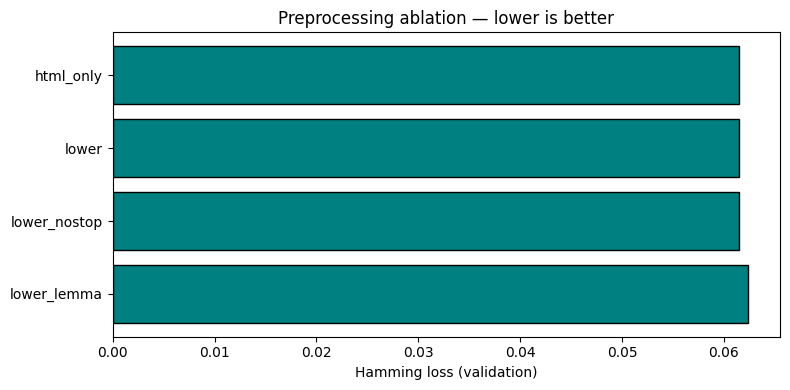

In [8]:
def quick_prep_eval(text_series, label=""):
    """Train/evaluate one preprocessing variant with baseline TF-IDF + LogReg."""
    idx = np.arange(len(text_series))
    idx_tr, idx_va = train_test_split(idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    vec = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2, stop_words="english")
    X_tr = vec.fit_transform(text_series.iloc[idx_tr])
    X_va = vec.transform(text_series.iloc[idx_va])
    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    )
    clf.fit(X_tr, y[idx_tr])
    y_pred = clf.predict(X_va)
    return {
        "variant": label,
        "hamming_loss": hamming_loss(y[idx_va], y_pred),
        "f1_micro": f1_score(y[idx_va], y_pred, average="micro", zero_division=0),
    }


prep_ablation = []
for name in PREP_VARIANTS:
    metrics = quick_prep_eval(train_df[f"prep_{name}"], label=name)
    prep_ablation.append(metrics)
    print(f"P-{name}: Hamming loss={metrics['hamming_loss']:.4f} | F1 micro={metrics['f1_micro']:.4f}")

prep_ablation_df = pd.DataFrame(prep_ablation).sort_values("hamming_loss")
display(prep_ablation_df)

best_prep = prep_ablation_df.iloc[0]["variant"]
train_df["clean_text"] = train_df[f"prep_{best_prep}"]
test_df["clean_text"] = test_df[f"prep_{best_prep}"]
print(f"\nBest preprocessing variant: {best_prep} — using for all downstream experiments")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(prep_ablation_df["variant"], prep_ablation_df["hamming_loss"], color="teal", edgecolor="black")
ax.set_xlabel("Hamming loss (validation)")
ax.set_title("Preprocessing ablation — lower is better")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## STEP 5: Experiment 1

**Setup:** TF-IDF + One-vs-Rest Logistic Regression on cleaned text.  
**Metric:** Hamming loss (lower is better).

In [10]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

X = train_df["clean_text"]
y = Y  # binary matrix from STEP 3

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english",
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

baseline_model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
)
baseline_model.fit(X_train_tfidf, y_train)

y_val_pred = baseline_model.predict(X_val_tfidf)

val_hamming = hamming_loss(y_val, y_val_pred)
val_f1_micro = f1_score(y_val, y_val_pred, average="micro", zero_division=0)
val_f1_macro = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

print("Experiment 1")
print(f"  Validation Hamming loss : {val_hamming:.4f}  (lower is better)")
print(f"  Validation F1 (micro)   : {val_f1_micro:.4f}")
print(f"  Validation F1 (macro)   : {val_f1_macro:.4f}")
print(f"  Train - val sizes       : {X_train_tfidf.shape[0]} - {X_val_tfidf.shape[0]}")
print(f"  TF-IDF features         : {X_train_tfidf.shape[1]}")

Experiment 1
  Validation Hamming loss : 0.0615  (lower is better)
  Validation F1 (micro)   : 0.6200
  Validation F1 (macro)   : 0.5496
  Train - val sizes       : 2396 - 599
  TF-IDF features         : 15000


## STEP 6: Results — classification report, confusion matrices, learning curves

For Experiment 1 (baseline) on the validation set we report:
- **Per-label precision / recall / F1** (full multi-label classification report)
- **Confusion matrices** for the most frequent labels
- **Learning curve** (Hamming loss vs. training set size) to check bias/variance


Multi-label classification report — Experiment 1 (validation):



,indicator,precision,recall,f1,support
4,"3.3.1 - Number of new HIV infections per 1,000...",0.890,0.833,0.861,78
6,"3.3.3 - Malaria incidence per 1,000 population",0.838,0.689,0.756,45
5,"3.3.2 - Tuberculosis incidence per 100,000 pop...",0.773,0.723,0.747,47
23,3.b.2 - Total net official development assista...,0.732,0.749,0.740,215
9,3.4.1 - Mortality rate attributed to cardiovas...,0.723,0.731,0.727,93
15,3.7.2 - Adolescent birth rate (aged 10_14 year...,0.733,0.688,0.710,32
21,3.a.1 - Age-standardized prevalence of current...,0.667,0.750,0.706,16
14,3.7.1 - Proportion of women of reproductive ag...,0.622,0.657,0.639,35
19,3.9.2 - Mortality rate attributed to unsafe wa...,0.553,0.722,0.627,36
8,3.3.5 - Number of people requiring interventio...,0.561,0.676,0.613,34


                                          precision    recall  f1-score   support

        3.1.1 - Maternal mortality ratio       0.43      0.63      0.51        30
3.1.2 - Proportion of births attended by       0.29      0.39      0.33        18
          3.2.1 - Under-5 mortality rate       0.55      0.60      0.57        45
         3.2.2 - Neonatal mortality rate       0.41      0.37      0.39        19
3.3.1 - Number of new HIV infections per       0.89      0.83      0.86        78
3.3.2 - Tuberculosis incidence per 100,0       0.77      0.72      0.75        47
3.3.3 - Malaria incidence per 1,000 popu       0.84      0.69      0.76        45
3.3.4 - Hepatitis B incidence per 100,00       0.60      0.35      0.44        17
3.3.5 - Number of people requiring inter       0.56      0.68      0.61        34
3.4.1 - Mortality rate attributed to car       0.72      0.73      0.73        93
          3.4.2 - Suicide mortality rate       0.35      0.73      0.47        11
3.5.1 - Coverag

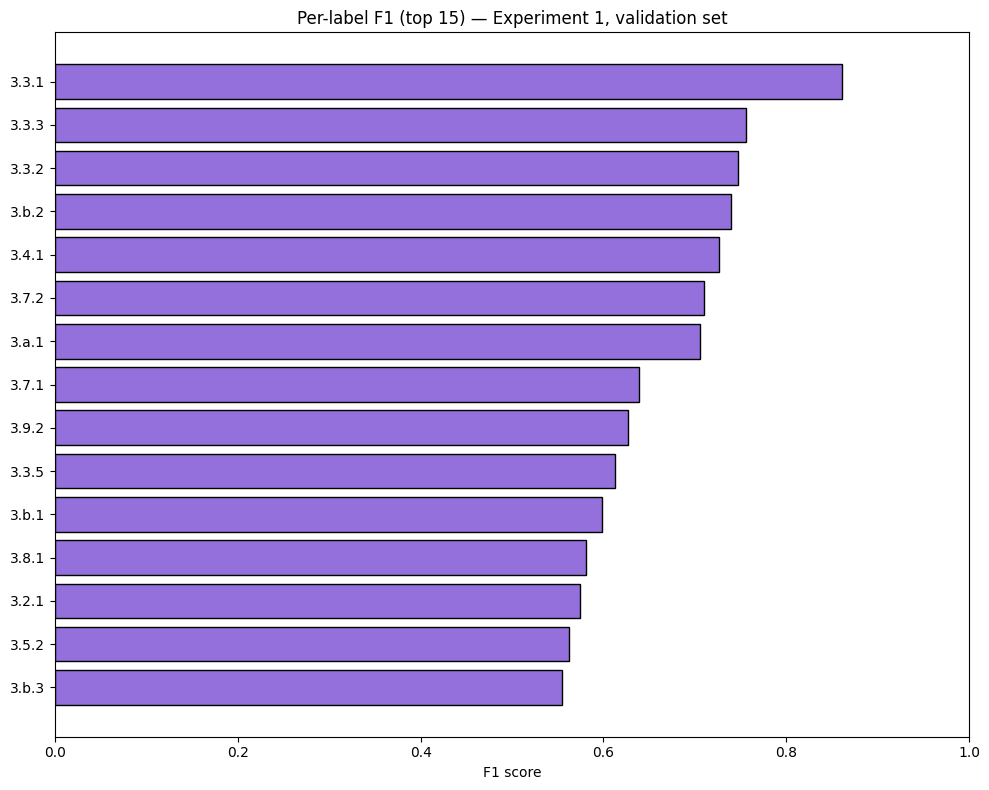

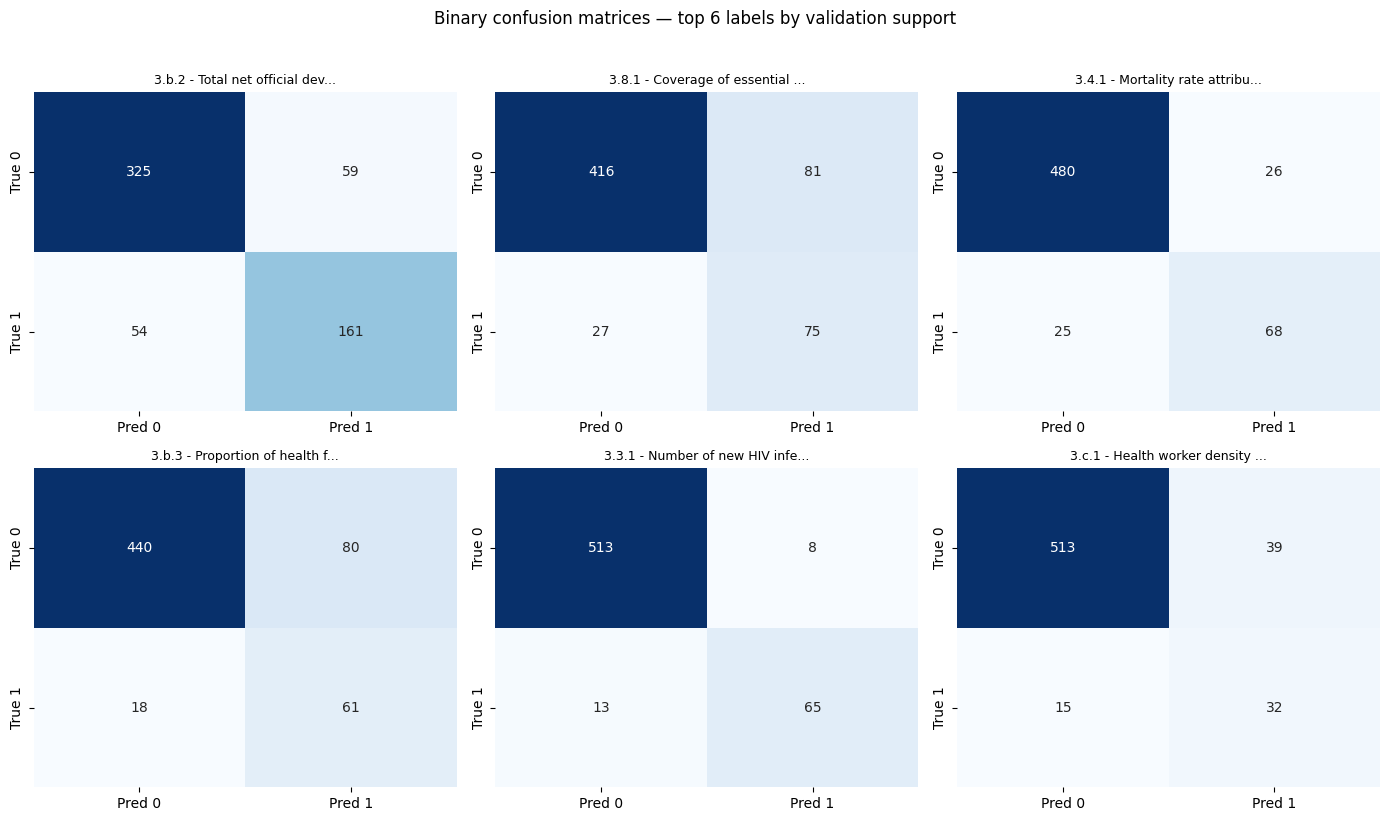

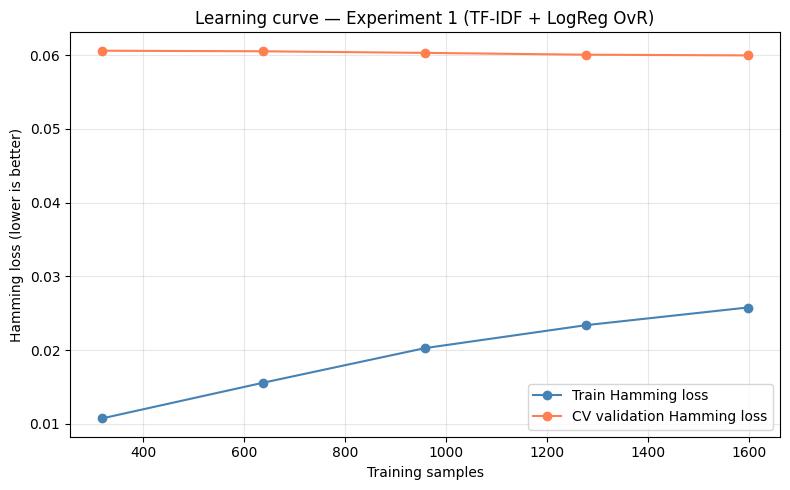

Learning curve summary:
  n= 319  train HL=0.0108  CV val HL=0.0606
  n= 638  train HL=0.0156  CV val HL=0.0605
  n= 958  train HL=0.0203  CV val HL=0.0603
  n=1277  train HL=0.0234  CV val HL=0.0601
  n=1597  train HL=0.0258  CV val HL=0.0600


,experiment,what_changed,hamming_loss,f1_micro,f1_macro
0,1,"TF-IDF (1–2 grams) + LogReg OvR, best preproce...",0.06146,0.620031,0.549612


In [11]:
def multilabel_report(y_true, y_pred, classes):
    """Build per-label precision/recall/F1/support table."""
    prec = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    support = y_true.sum(axis=0)
    df = pd.DataFrame({
        "indicator": classes,
        "precision": prec.round(3),
        "recall": rec.round(3),
        "f1": f1.round(3),
        "support": support.astype(int),
    }).sort_values("f1", ascending=False)
    return df


report_df = multilabel_report(y_val, y_val_pred, label_names)
print("Multi-label classification report — Experiment 1 (validation):\n")
display(report_df)

# Sklearn-style text summary for top labels
print(classification_report(
    y_val, y_val_pred,
    target_names=[n[:40] for n in label_names],
    zero_division=0,
))

# Per-label F1 bar chart (top 15)
fig, ax = plt.subplots(figsize=(10, 8))
plot_df = report_df.head(15).iloc[::-1]
short_names = plot_df["indicator"].str.replace(r"^(\d+\.\S+) - .*", r"\1", regex=True)
ax.barh(short_names, plot_df["f1"], color="mediumpurple", edgecolor="black")
ax.set_xlim(0, 1)
ax.set_xlabel("F1 score")
ax.set_title("Per-label F1 (top 15) — Experiment 1, validation set")
plt.tight_layout()
plt.show()

# Confusion matrices for top 6 labels by support
top6_idx = np.argsort(y_val.sum(axis=0))[::-1][:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
mcm = multilabel_confusion_matrix(y_val, y_val_pred)
for ax, li in zip(axes.ravel(), top6_idx):
    tn, fp, fn, tp = mcm[li].ravel()
    sns.heatmap(
        np.array([[tn, fp], [fn, tp]]),
        annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"],
    )
    short = label_names[li][:30] + ("..." if len(label_names[li]) > 30 else "")
    ax.set_title(short, fontsize=9)
fig.suptitle("Binary confusion matrices — top 6 labels by validation support", y=1.02)
plt.tight_layout()
plt.show()

# Learning curve (Hamming loss) — use fractions so sizes respect CV fold limits
train_sizes = np.linspace(0.2, 1.0, 5)

def hamming_scorer(estimator, X, y_true):
    return -hamming_loss(y_true, estimator.predict(X))

lc_estimator = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
)
train_sz, train_scores, val_scores = learning_curve(
    lc_estimator, X_train_tfidf, y_train,
    train_sizes=train_sizes, cv=3, scoring=hamming_scorer, n_jobs=-1,
)
train_hl = -train_scores.mean(axis=1)
val_hl = -val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sz, train_hl, "o-", label="Train Hamming loss", color="steelblue")
ax.plot(train_sz, val_hl, "o-", label="CV validation Hamming loss", color="coral")
ax.set_xlabel("Training samples")
ax.set_ylabel("Hamming loss (lower is better)")
ax.set_title("Learning curve — Experiment 1 (TF-IDF + LogReg OvR)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
os.makedirs("results", exist_ok=True)
fig.savefig("results/experiment1_learning_curve.png", dpi=150)
plt.show()

print("Learning curve summary:")
for n, tr, va in zip(train_sz, train_hl, val_hl):
    print(f"  n={int(n):4d}  train HL={tr:.4f}  CV val HL={va:.4f}")

# Experiment tracking table (STEP 8 runs experiments 1–10 and replaces this)
experiments = pd.DataFrame([
    {
        "experiment": 1,
        "what_changed": "TF-IDF (1–2 grams) + LogReg OvR, best preprocessing",
        "hamming_loss": val_hamming,
        "f1_micro": val_f1_micro,
        "f1_macro": val_f1_macro,
    }
])
display(experiments)
